Continuation of [jax_wcs_experimentation_part3.ipynb](jax_wcs_experimentation_part3.ipynb)

In [1]:
import time
from pathlib import Path
from matplotlib import pyplot as plt

import numpy as np

from jwst import datamodels

from astropy import units as u
from astropy.coordinates import SkyCoord, SpectralCoord

import jax
from jax import numpy as jnp
import equinox as eqx
import optax

from tqdm.auto import tqdm

jax.devices()

Jax plugin configuration error: Exception when calling jax_plugins.xla_cuda12.initialize()
Traceback (most recent call last):
  File "/var/home/erik/astro/m31_jwst_2609_vol2/.pixi/envs/gpu/lib/python3.14/site-packages/jax/_src/xla_bridge.py", line 487, in discover_pjrt_plugins
    plugin_module.initialize()
    ~~~~~~~~~~~~~~~~~~~~~~~~^^
  File "/var/home/erik/astro/m31_jwst_2609_vol2/.pixi/envs/gpu/lib/python3.14/site-packages/jax_plugins/xla_cuda12/__init__.py", line 370, in initialize
    _check_cuda_versions(raise_on_first_error = True)
    ~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/var/home/erik/astro/m31_jwst_2609_vol2/.pixi/envs/gpu/lib/python3.14/site-packages/jax_plugins/xla_cuda12/__init__.py", line 274, in _check_cuda_versions
    for d in range(cuda_versions.cuda_device_count())
                   ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~^^
RuntimeError: jaxlib/cuda/versions_helpers.cc:134: operation cuInit(0) failed: CUDA_ERROR_NO_DEVICE


[CpuDevice(id=0)]

# Data

In [3]:
n6791fits = list(Path('../ngc6791_cals').glob('*.fits'))
n6791dms = [datamodels.open(fn) for fn in n6791fits]

dm0 = n6791dms[0]
s = dm0.slits[42]
swcs = s.meta.wcs

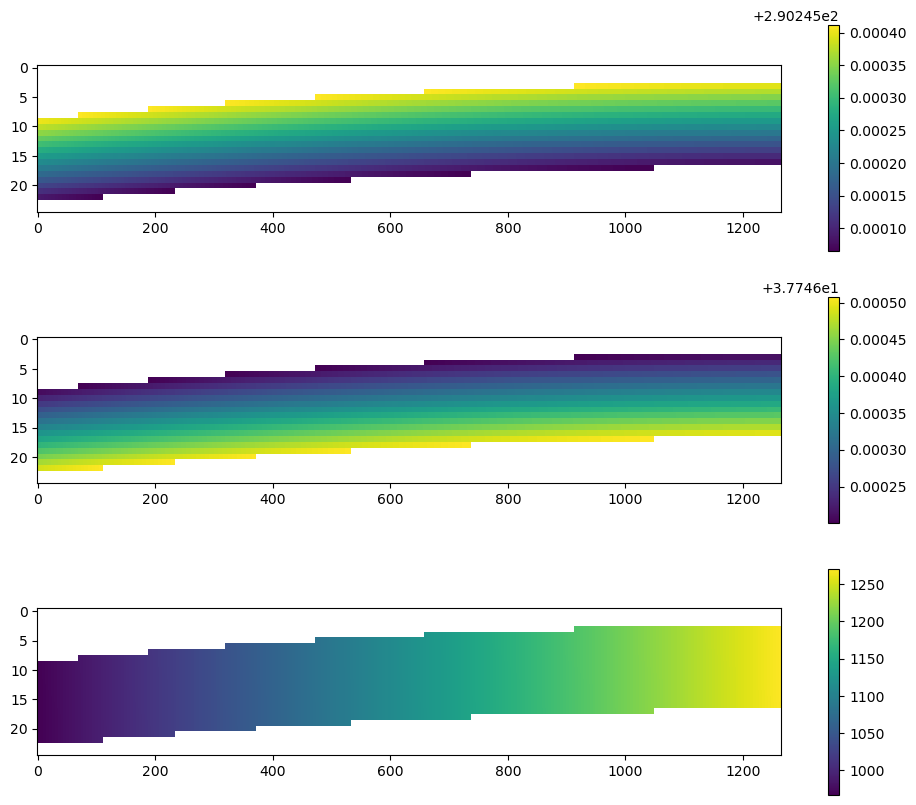

In [3]:
yg, xg = np.indices(s.data.shape)

sky,spec = swcs.pixel_to_world(xg, yg)
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 10))

sc = ax1.imshow(sky.ra.deg, aspect=10, interpolation='nearest')
plt.colorbar(sc, ax=ax1)
sc = ax2.imshow(sky.dec.deg, aspect=10, interpolation='nearest')
plt.colorbar(sc, ax=ax2)
sc = ax3.imshow(spec.to_value(u.nm), aspect=10, interpolation='nearest')
plt.colorbar(sc, ax=ax3)

In [4]:
class SlitScaling:
    def __init__(self, slitshape, wcs, extra_in_offset=1): # not slitshape will be y,x not x,y despite wcs being the normal way
        self.slitshape = slitshape
        self.wcs = wcs
        self.extra_in_offset = extra_in_offset

        self._compute_inbounds()
        self._compute_outbounds()

    def _compute_inbounds(self):
        self.inscale = jnp.array((self.slitshape[1], self.slitshape[0]))
        self.inoffset = -self.extra_in_offset * jnp.ones(2)

    def _compute_outbounds(self):
        world = self.world_grid()
        worldflat = world.reshape(3, -1)
        self.outoffset = mi = jnp.nanmin(worldflat, axis=1)
        mx = jnp.nanmax(worldflat, axis=1)
        self.outscale = mx - mi

    def xy_grid(self):
        yg, xg = jnp.mgrid[:self.slitshape[0], :self.slitshape[1]]
        return jnp.stack([xg, yg[::-1]], axis=0)
    
    def xy_grid_rescaled(self):
        return self.rescale_input(self.xy_grid())

    def world_grid(self):
        return jnp.array(self.wcs.pixel_to_world_values(*self.xy_grid()))
    
    def world_grid_rescaled(self):
        return self.rescale_output(self.world_grid())
    
    def rescale_input(self, xy):
        return ((xy.T - self.inoffset) / self.inscale).T * 2 - 1
    
    def rescale_output(self, out):
        return ((out.T - self.outoffset) / self.outscale).T * 2 - 1

    def restore_output(self, outscaled):
        return ((outscaled+1/2).T * self.outscale + self.outoffset).T
    
ss = SlitScaling(s.data.shape, swcs)

In [ ]:
xygrf = ss.xy_grid_rescaled().reshape(2, -1)

deg = [15, 15]
vander = np.polynomial.legendre.legvander2d(xygrf[0], xygrf[1], deg)
#vander = np.polynomial.chebyshev.chebvander2d(xygrf[0], xygrf[1], deg)
#vander = np.polynomial.hermite.hermvander2d(xygrf[0], xygrf[1], deg)

worldf = ss.world_grid().reshape(3, -1)
msk = np.isfinite(worldf).all(axis=0)
worldf = worldf[:, msk]
vanderf = vander[msk]

res = np.linalg.lstsq(vanderf, worldf.T, rcond=None)
res

(array([[ 4.02601774e-09,  5.23570631e-10,  2.19953084e-11],
        [-1.14269649e-09, -1.48606155e-10, -5.14688986e-12],
        [-6.36563358e-10, -8.27827459e-11, -3.61405740e-12],
        [ 9.10335141e-10,  1.18387161e-10,  4.47577305e-12],
        [ 3.34073014e-09,  4.34461689e-10,  1.27761994e-11],
        [ 1.07899223e-09,  1.40323808e-10,  3.40551871e-12],
        [-1.62420726e-08, -2.11227968e-09, -6.23605473e-11],
        [-1.51712580e-08, -1.97303152e-09, -5.04162233e-11],
        [ 9.95225662e-08,  1.29429001e-08,  3.81123050e-10],
        [ 1.76685489e-07,  2.29780603e-08,  5.87448701e-10],
        [-4.09979918e-07, -5.33178905e-08, -1.54788904e-09],
        [-2.21791220e-06, -2.88440901e-07, -7.38275752e-09],
        [-3.71342298e-06, -4.82929522e-07, -1.46683048e-08],
        [ 2.44141556e-05,  3.17507670e-06,  8.14536349e-08],
        [ 2.64063474e-05,  3.43414013e-06,  1.02083895e-07],
        [-2.67004748e-06, -3.47238057e-07, -1.11233422e-08],
        [ 2.10594541e-12

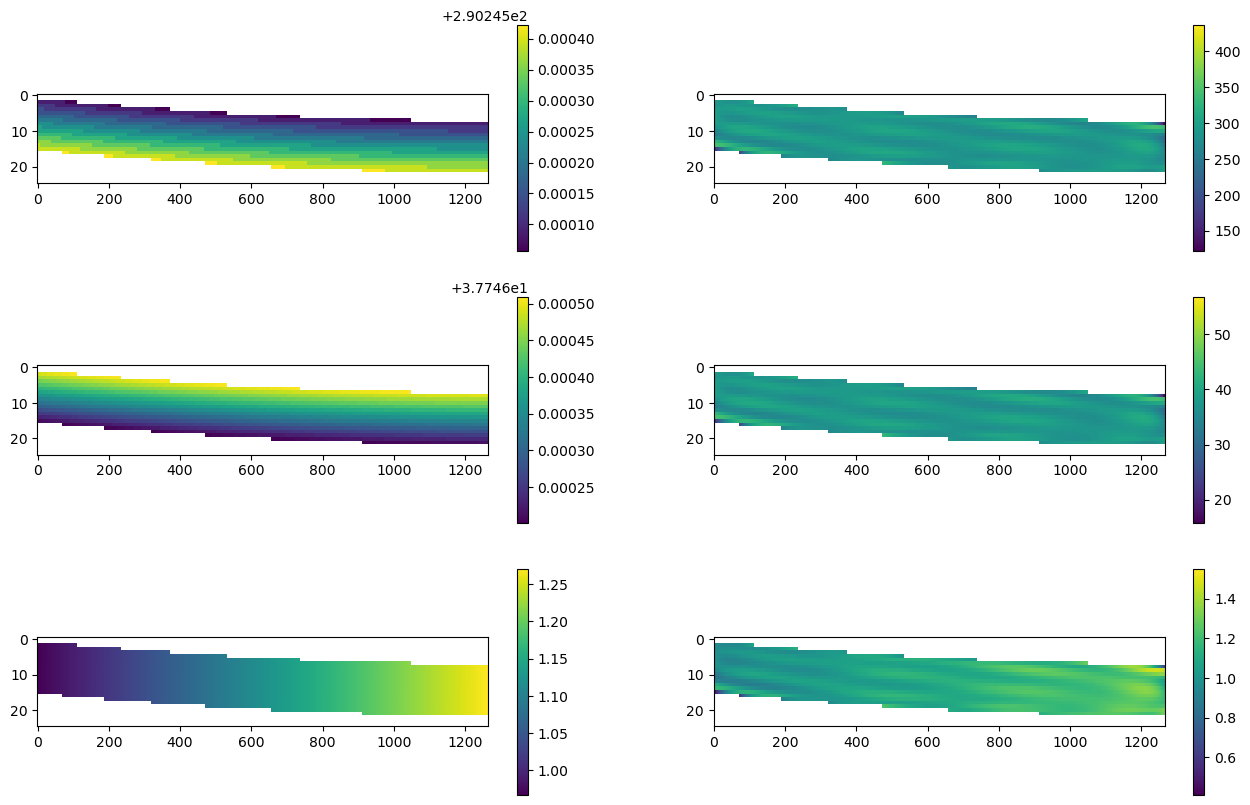

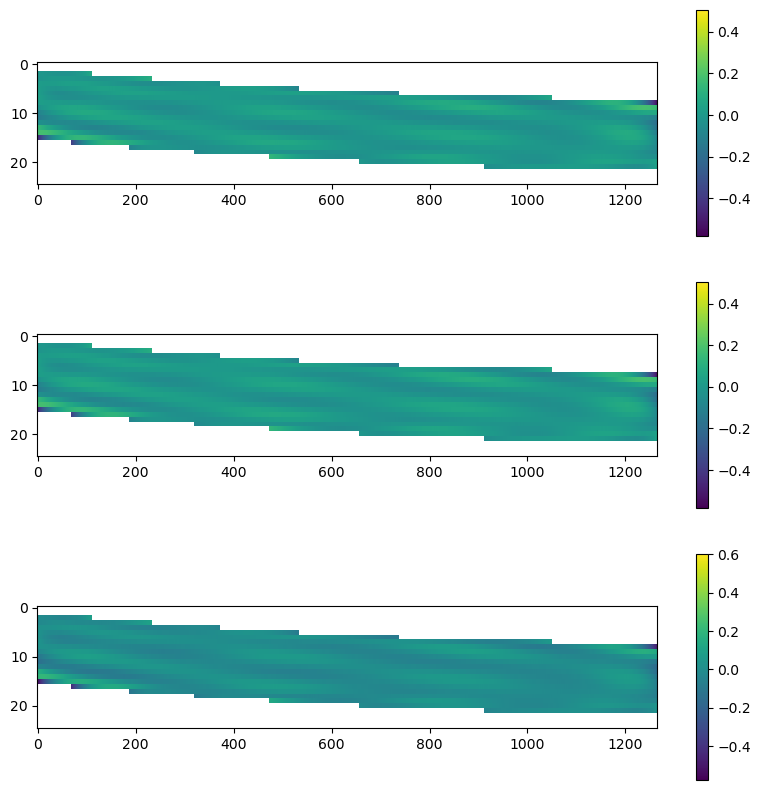

In [53]:
coeffs = res[0]
vals = (vander @ coeffs).T.reshape(3, *ss.slitshape)

worldg = ss.world_grid()

fig, axs = plt.subplots(3, 2, figsize=(16, 10))
for i, (ax1, ax2) in enumerate(axs):
    sc = ax1.imshow(worldg[i], aspect=10, interpolation='nearest')
    plt.colorbar(sc, ax=ax1)
    sc = ax2.imshow(vals[i] + (worldg[i] - worldg[i]), aspect=10, interpolation='nearest')
    plt.colorbar(sc, ax=ax2)

fig, axs = plt.subplots(3, 1, figsize=(10, 10))
for i, ax in enumerate(axs):
    sc = ax.imshow(vals[i]/worldg[i] - 1, aspect=10, interpolation='nearest')
    plt.colorbar(sc, ax=ax)

/tmp/ipykernel_181176/1497889934.py:25: RuntimeWarning: divide by zero encountered in divide
  sc = ax.imshow((dv-dw)/dw, aspect=10, interpolation='nearest')
/tmp/ipykernel_181176/1497889934.py:25: RuntimeWarning: invalid value encountered in divide
  sc = ax.imshow((dv-dw)/dw, aspect=10, interpolation='nearest')


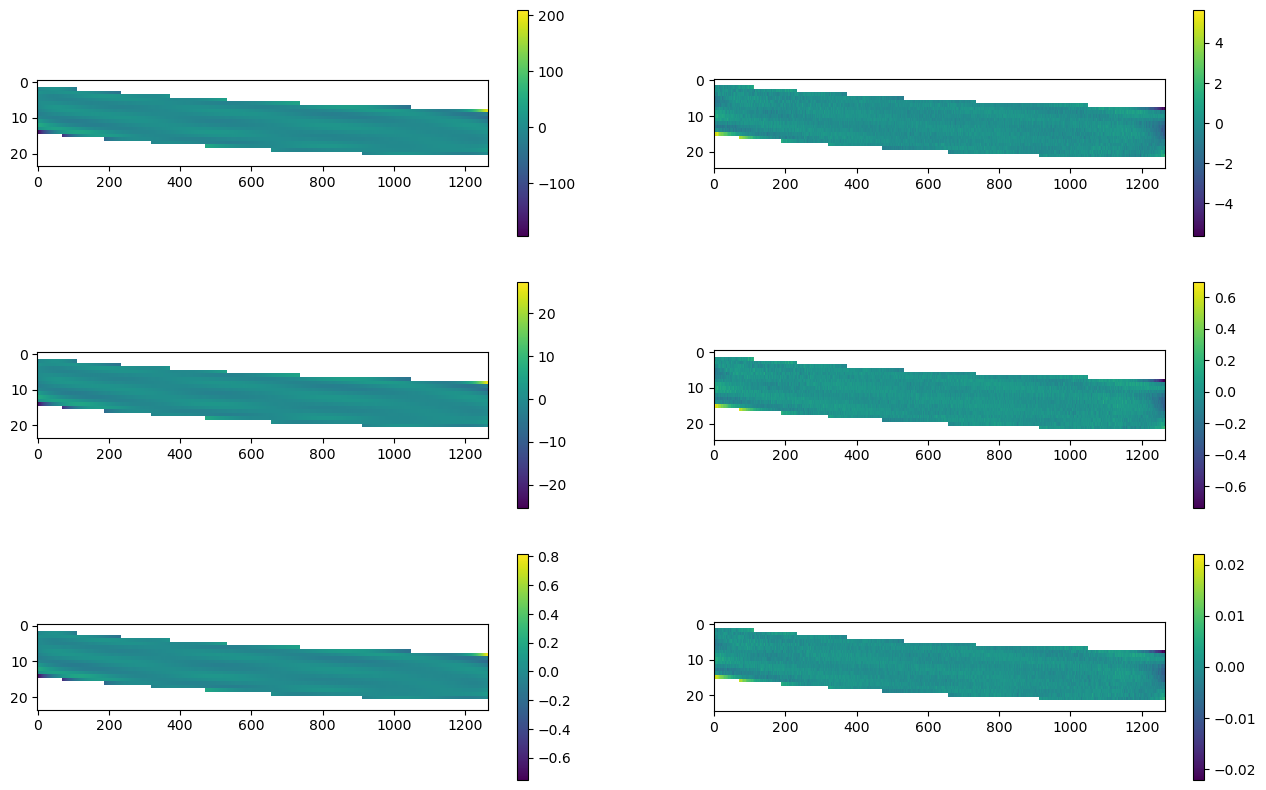

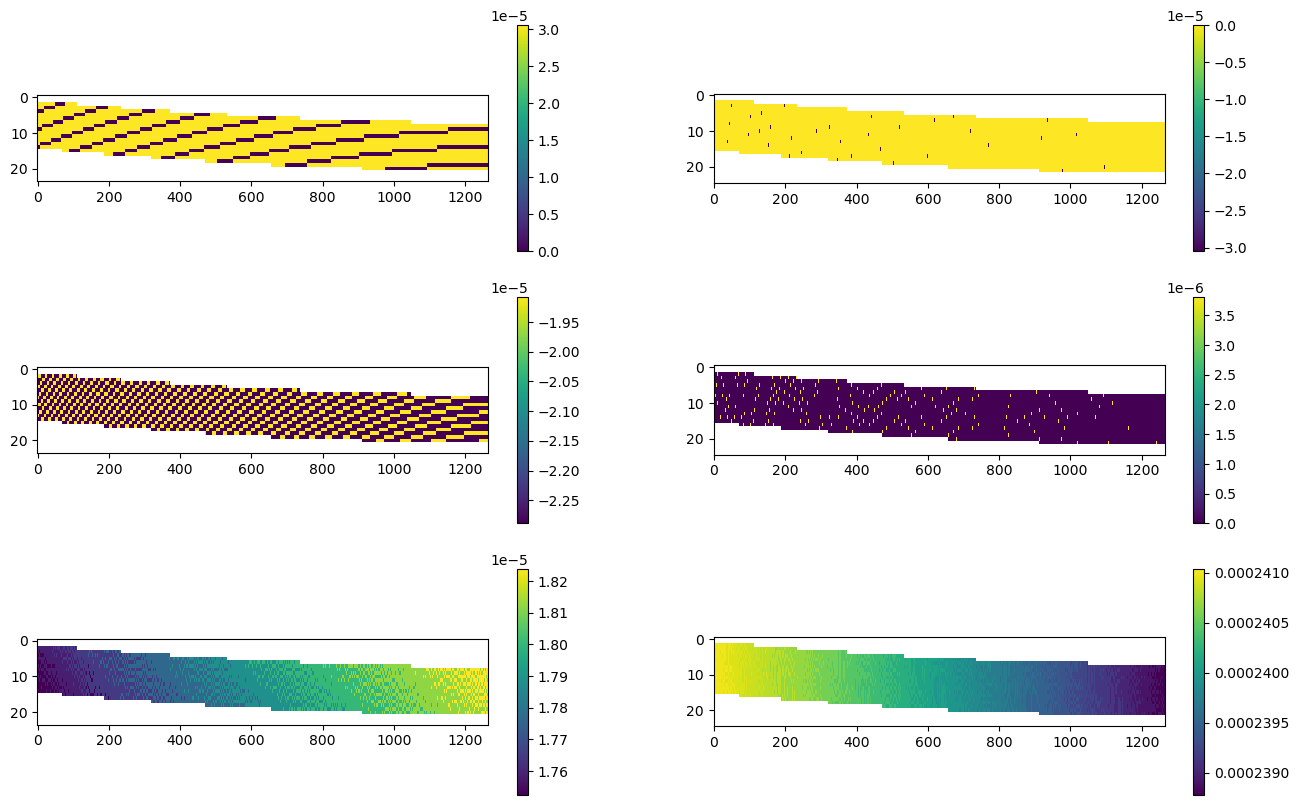

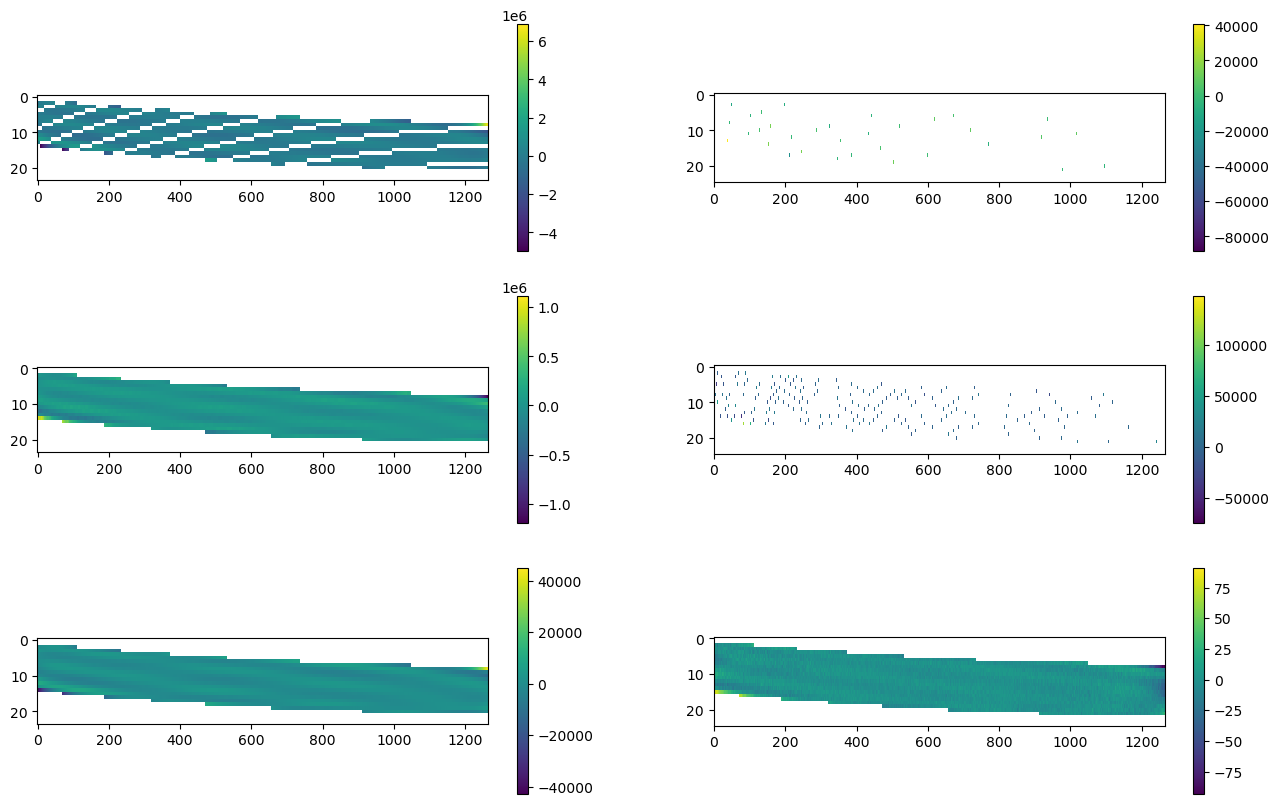

In [54]:
fig, axs = plt.subplots(3, 2, figsize=(16, 10))
for i, axs in enumerate(axs):
    for j in range(2):
        ax = axs[j]
        dv = np.diff(vals[i], axis=j)
        dw = np.diff(worldg[i], axis=j)
        sc = ax.imshow(dv + (dw-dw), aspect=10, interpolation='nearest')
        plt.colorbar(sc, ax=ax)

fig, axs = plt.subplots(3, 2, figsize=(16, 10))
for i, axs in enumerate(axs):
    for j in range(2):
        ax = axs[j]
        dv = np.diff(vals[i], axis=j)
        dw = np.diff(worldg[i], axis=j)
        sc = ax.imshow(dw, aspect=10, interpolation='nearest')
        plt.colorbar(sc, ax=ax)

fig, axs = plt.subplots(3, 2, figsize=(16, 10))
for i, axs in enumerate(axs):
    for j in range(2):
        ax = axs[j]
        dv = np.diff(vals[i], axis=j)
        dw = np.diff(worldg[i], axis=j)
        sc = ax.imshow((dv-dw)/dw, aspect=10, interpolation='nearest')
        plt.colorbar(sc, ax=ax)

Even High degree polys are a mess.  Maybe need to also rescale?

In [69]:
xygrf = ss.xy_grid_rescaled().reshape(2, -1)

deg = [15, 15]
vander = np.polynomial.legendre.legvander2d(xygrf[0], xygrf[1], deg)
#vander = np.polynomial.chebyshev.chebvander2d(xygrf[0], xygrf[1], deg)
#vander = np.polynomial.hermite.hermvander2d(xygrf[0], xygrf[1], deg)

worldsc = ss.world_grid_rescaled().reshape(3, -1)
msk = np.isfinite(worldsc).all(axis=0)
worldsc = worldsc[:, msk]
vanderf = vander[msk]

res = np.linalg.lstsq(vanderf, worldsc.T, rcond=None)
res

(array([[ 1.78083044e+03,  4.40157654e+02,  3.13566998e-02],
        [ 1.16123975e+04,  3.15235620e+03,  2.61970237e-02],
        [ 1.20235498e+04,  1.98746301e+03,  1.27173886e-01],
        [ 1.50024277e+04,  4.70759277e+03,  4.00566012e-02],
        [ 2.60571387e+04,  2.69485498e+03,  1.48479611e-01],
        [ 7.01936865e+03,  3.17652832e+03,  2.50086337e-02],
        [ 3.12144609e+04,  2.26617456e+03,  1.04434401e-01],
        [ 8.20559204e+02,  1.12021509e+03,  6.81381673e-03],
        [ 2.23729160e+04,  1.23105310e+03,  4.72299010e-02],
        [ 1.98095718e+02,  1.56695740e+02, -7.25578866e-04],
        [ 9.69137793e+03,  4.10761261e+02,  1.30766239e-02],
        [ 7.17747620e+02, -6.99746037e+00, -1.16185681e-03],
        [ 2.37196338e+03,  7.39468307e+01,  1.89850945e-03],
        [ 4.10152161e+02,  2.28498721e+00, -3.64733307e-04],
        [ 2.56016937e+02,  5.11255312e+00,  9.16823628e-05],
        [ 7.13369446e+01,  1.91339588e+00, -4.48084465e-05],
        [ 7.63296240e+03

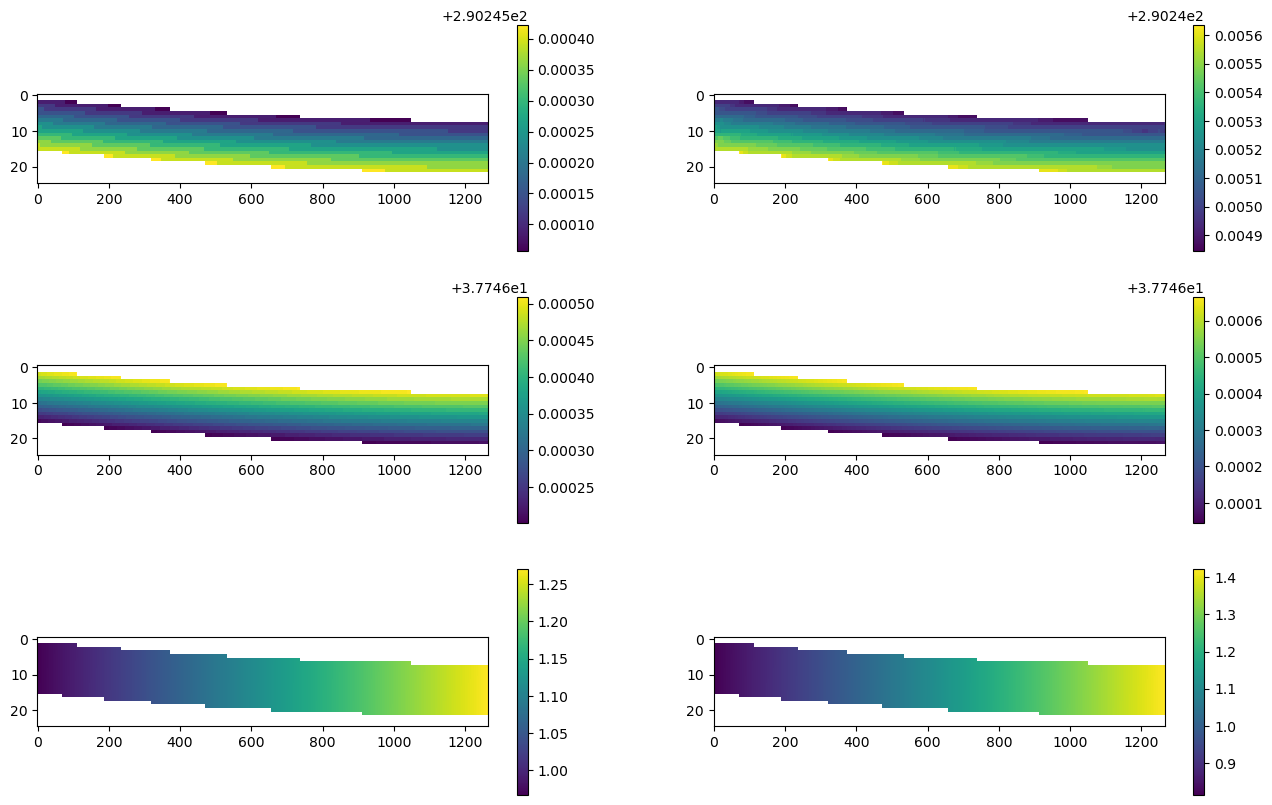

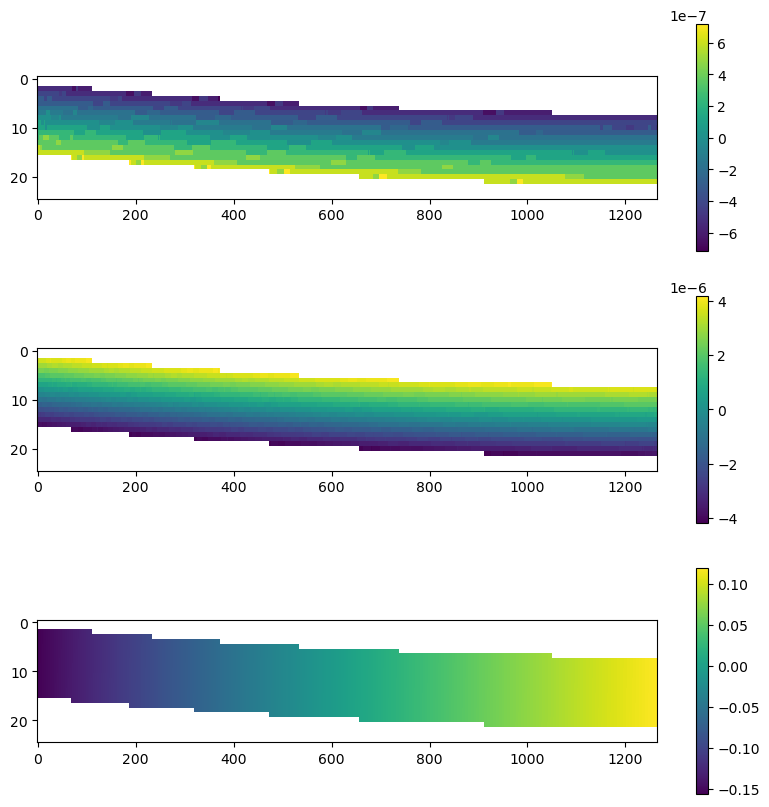

In [70]:
coeffs = res[0]
vals = ss.restore_output((vander @ coeffs).T.reshape(3, *ss.slitshape))

worldg = ss.world_grid()

fig, axs = plt.subplots(3, 2, figsize=(16, 10))
for i, (ax1, ax2) in enumerate(axs):
    sc = ax1.imshow(worldg[i], aspect=10, interpolation='nearest')
    plt.colorbar(sc, ax=ax1)
    sc = ax2.imshow(vals[i] + (worldg[i] - worldg[i]), aspect=10, interpolation='nearest')
    plt.colorbar(sc, ax=ax2)

fig, axs = plt.subplots(3, 1, figsize=(10, 10))
for i, ax in enumerate(axs):
    sc = ax.imshow(vals[i]/worldg[i] - 1, aspect=10, interpolation='nearest')
    plt.colorbar(sc, ax=ax)

/tmp/ipykernel_181176/1497889934.py:25: RuntimeWarning: divide by zero encountered in divide
  sc = ax.imshow((dv-dw)/dw, aspect=10, interpolation='nearest')
/tmp/ipykernel_181176/1497889934.py:25: RuntimeWarning: invalid value encountered in divide
  sc = ax.imshow((dv-dw)/dw, aspect=10, interpolation='nearest')


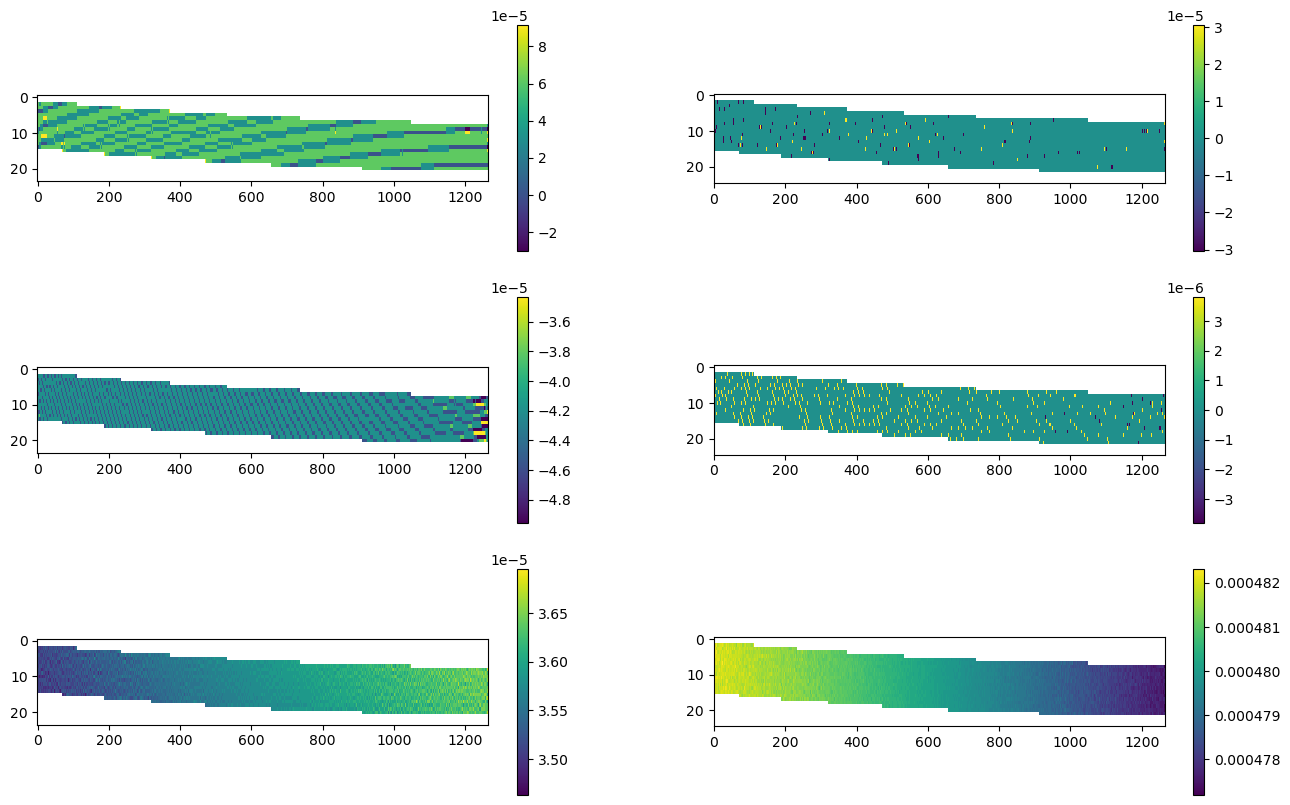

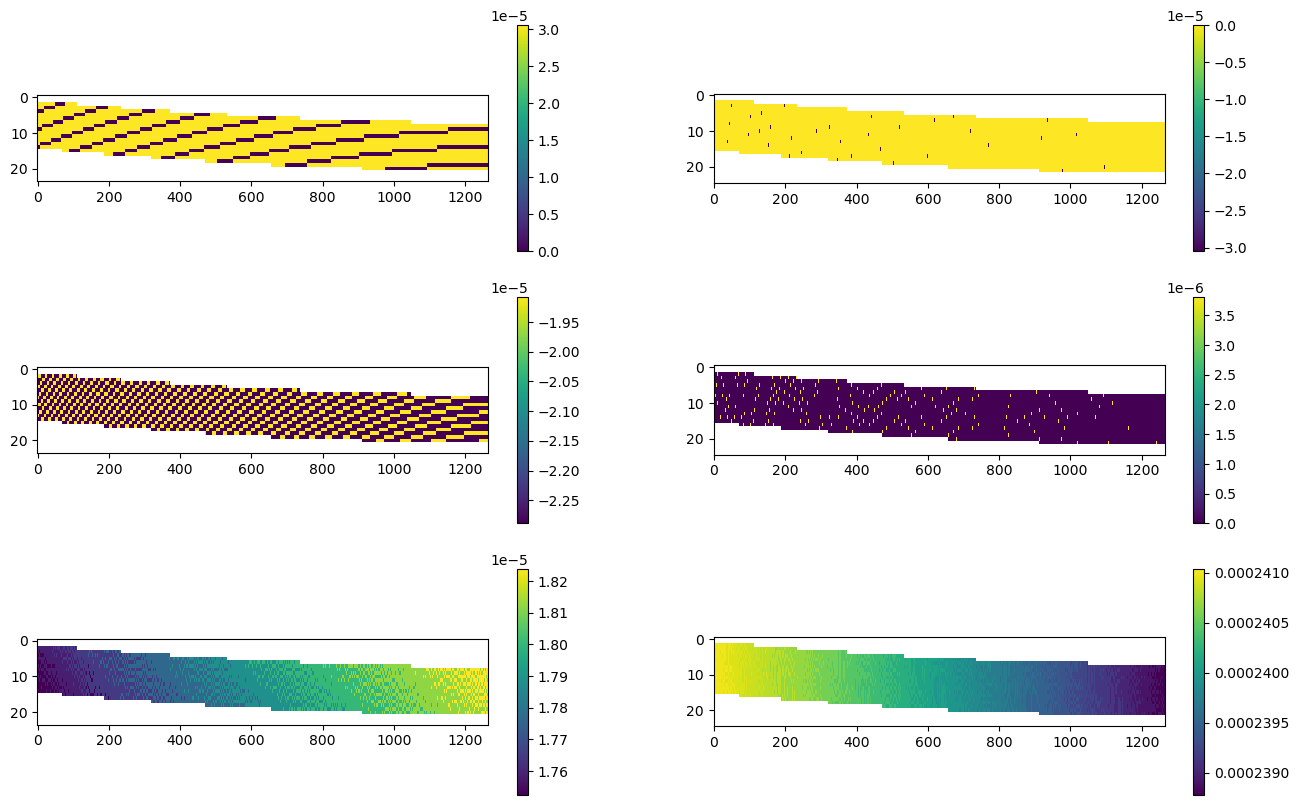

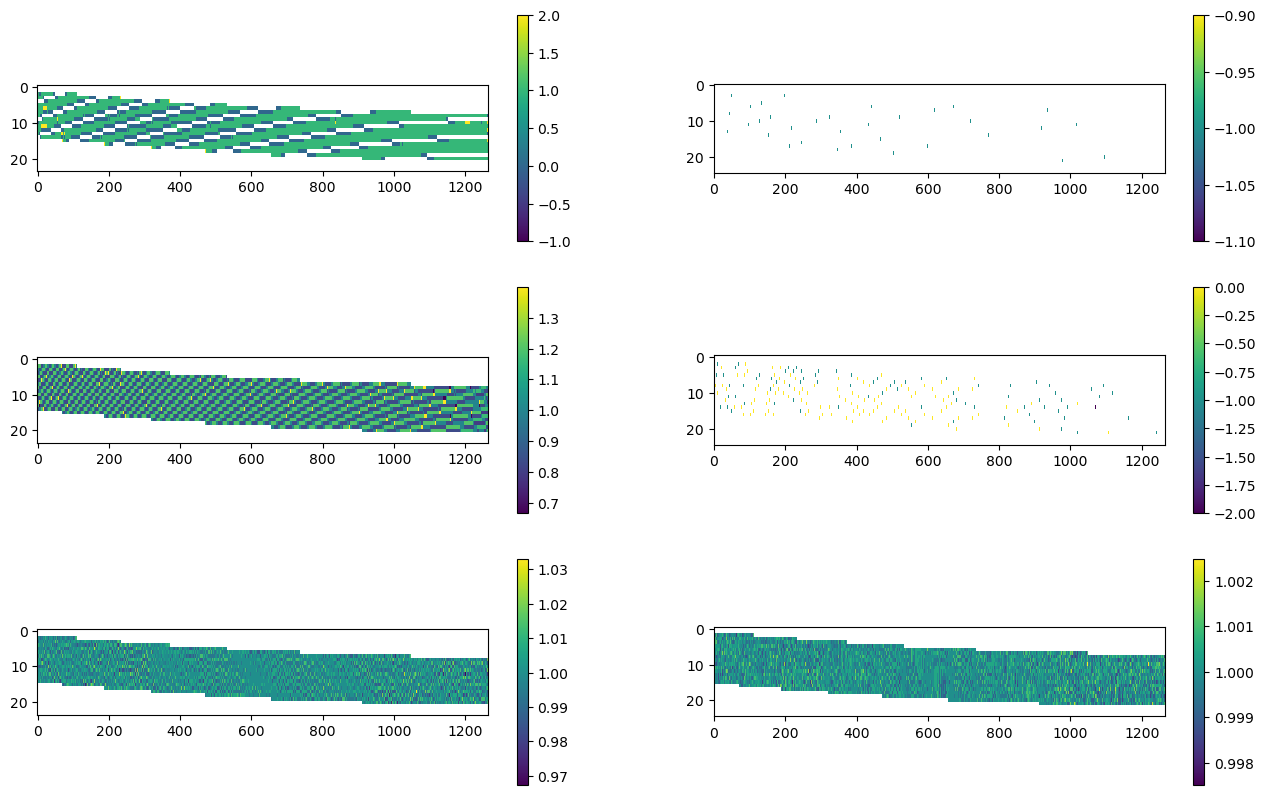

In [57]:
fig, axs = plt.subplots(3, 2, figsize=(16, 10))
for i, axs in enumerate(axs):
    for j in range(2):
        ax = axs[j]
        dv = np.diff(vals[i], axis=j)
        dw = np.diff(worldg[i], axis=j)
        sc = ax.imshow(dv + (dw-dw), aspect=10, interpolation='nearest')
        plt.colorbar(sc, ax=ax)

fig, axs = plt.subplots(3, 2, figsize=(16, 10))
for i, axs in enumerate(axs):
    for j in range(2):
        ax = axs[j]
        dv = np.diff(vals[i], axis=j)
        dw = np.diff(worldg[i], axis=j)
        sc = ax.imshow(dw, aspect=10, interpolation='nearest')
        plt.colorbar(sc, ax=ax)

fig, axs = plt.subplots(3, 2, figsize=(16, 10))
for i, axs in enumerate(axs):
    for j in range(2):
        ax = axs[j]
        dv = np.diff(vals[i], axis=j)
        dw = np.diff(worldg[i], axis=j)
        sc = ax.imshow((dv-dw)/dw, aspect=10, interpolation='nearest')
        plt.colorbar(sc, ax=ax)